## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub by clicking the link below. If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 


Access the [**Global Ecosystem Dynamics Investigation (GEDI) Aboveground Biomass Density**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Fgedi-agb-grid-v2.1_User_Notebook.ipynb&branch=main) notebook in the US GHG Center JupyterHub (requires access).

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Terminology](#terminology)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Create GEDI Legend](#create-gedi-legend)
- [GEDI Ecoregion Assessment](#gedi-ecoregion-assessment)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global between (51.6°N to 51.6°S) and (-180.0°W to 180.0°E)
- **Spatial resolution**: 1 km × 1 km
- **Temporal extent**: April 2019 - March 2023
- **Unit**: Megagrams of aboveground biomass density per hectare (Mg/ha)
- **Utility**: Forest Carbon Monitoring and Climate Research

For more information, see the [GEDI Level-4B (L4B) Gridded Aboveground Biomass Density user guide](https://daac.ornl.gov/GEDI/guides/GEDI_L4B_Gridded_Biomass_V2_1.html).

## Approach

This notebook demonstrates how to visualize and compare GEDI aboveground biomass density data across different forest regions using STAC metadata and pre-rendered WMTS imagery:

1. **Connect to STAC API** - Access the GEDI biomass collection metadata from the US GHG Center.
2. **Define Tile Matrix** - Use the 1km tile matrix in EPSG:4326 projection for global coverage.
3. **Fetch GEDI Imagery** - Retrieve pre-rendered biomass density tiles from NASA GIBS WMTS service.
4. **Visualize Biomass Patterns** - Display biomass density using the gist_earth colormap with values up to 250 Mg/ha.
5. **Compare Forest Regions** - Analyze biomass differences between major forest ecosystems worldwide.
6. **Interactive Region Selection** - Input and compare high-biomass forest regions.
7. **Add Visual Enhancements** - Include coordinate grids, labels, and location markers for spatial context.
8. **Interpret Results** - Understand biomass distribution patterns and their importance for carbon monitoring.

## About the Data
### GEDI Aboveground Biomass Density
The Global Ecosystem Dynamics Investigation (GEDI) mission provides high-resolution laser ranging observations of Earth's 3D structure from the International Space Station (ISS). GEDI's L4B product delivers 1 km × 1 km mean aboveground biomass density (AGBD) estimates derived from GEDI's lidar waveform measurements. These estimates are crucial for understanding global carbon stocks and monitoring deforestation. The data covers global tropical and temperate forests between 51.6°N and 51.6°S latitude, providing unprecedented detail on forest structure and biomass distribution.

For more information regarding this dataset, please visit the [Global Ecosystem Dynamics Investigation (GEDI) Aboveground Biomass Density](https://earth.gov/ghgcenter/data-catalog/gedi-agb-grid-v2.1) data overview page.

## Terminology

Navigating data via the GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.

-  `catalog`:    All datasets available at the `/stac` endpoint
-  `collection`: A specific dataset, e.g. GEDI Aboveground Biomass Density
-  `item`:       One granule in the dataset, e.g. one file with mean AGBD
-  `asset`:      A variable available within the granule, e.g. biomass density
-  `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets

## Install the Required Libraries
Required libraries are pre-installed on the GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

`%pip install requests pystac_client matplotlib numpy ipywidgets pillow lxml owslib geopandas folium --quiet`

In [3]:
# Import required libraries
import requests
from datetime import datetime
from typing import List, Tuple, Dict
from io import BytesIO
import numpy as np
import xml.etree.ElementTree as xmlet
import lxml.etree as xmltree
from owslib.wms import WebMapService
import tempfile
import zipfile
from urllib.request import urlopen
import os

# For data visualization
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.gridspec import GridSpec
import geopandas as gpd

# For image processing
from PIL import Image as plimg
from PIL import ImageDraw
from IPython.display import Image, display

# For accessing the STAC API
from pystac_client import Client

# For interactive mapping
import folium
from folium.plugins import FloatImage

# For reading a file directly from the URL without downloading
import tempfile
import zipfile
from urllib.request import urlopen

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the GEDI Aboveground Biomass Density dataset is [**GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303**](https://earth.gov/ghgcenter/api/stac/collections/GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303).

**You can find the collection name of any dataset on the GHGC data portal by navigating to the dataset landing page within the data catalog. The collection name is the last portion of the dataset landing page's URL, and is also listed in the pop-up box after clicking "ACCESS DATA."*

In [4]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://dev.ghg.center/api/stac"

# The collection name is used to fetch metadata from the STAC API.
COLLECTION_NAME = "GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303"


In [5]:
# Load collection
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(COLLECTION_NAME)
display(collection)

<CollectionClient id=GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303>

Under `links`, you can see the WMTS URL for accessing GEDI imagery from GIBS:

In [6]:
GIBS_WMTS_URL = collection.links[4].href
GIBS_WMTS_URL

'https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/wmts.cgi'

In [7]:
# Use this URL to request WMTS capabilities
response = requests.get(GIBS_WMTS_URL.replace('wmts','wms')+"?SERVICE=WMS&REQUEST=GetCapabilities")

In [8]:
# Convert capability response to XML tree.
WmtsTree = xmlet.fromstring(response.content)

alllayer = []

# Parse capability XML tree to get a list and number of available layers.
for child in WmtsTree.iter():
    for layer in child.findall("./{http://www.opengis.net/wms}Capability/{http://www.opengis.net/wms}Layer//*/"): 
         if layer.tag == '{http://www.opengis.net/wms}Layer': 
            f = layer.find("{http://www.opengis.net/wms}Name")
            if f is not None:
                alllayer.append(f.text)

# Print the first five and last five layers.
print('Number of layers: ', len(alllayer))
for one in sorted(alllayer)[:5]:
    print(one)
print('...')
for one in sorted(alllayer)[-5:]:
    print(one)  

Number of layers:  1337
AIRS_L2_Carbon_Monoxide_500hPa_Volume_Mixing_Ratio_Day
AIRS_L2_Carbon_Monoxide_500hPa_Volume_Mixing_Ratio_Night
AIRS_L2_Cloud_Top_Height_Day
AIRS_L2_Cloud_Top_Height_Night
AIRS_L2_Dust_Score_Day
...
VIIRS_SNPP_SurfaceReflectance_BandsM11-M7-M5
VIIRS_SNPP_SurfaceReflectance_BandsM5-M4-M3
VIIRS_SNPP_Thermal_Anomalies_375m_All
VIIRS_SNPP_Thermal_Anomalies_375m_Day
VIIRS_SNPP_Thermal_Anomalies_375m_Night


In [9]:
# Search for GEDI L4B layers
GEDI_L4B_LAYERS = [l for l in alllayer if ('GEDI' in l) and ('L4B' in l)]
GEDI_L4B_LAYERS

['GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303',
 'GEDI_ISS_L4B_Aboveground_Biomass_Density_PercentStandardError_201904-202303',
 'GEDI_ISS_L4B_Aboveground_Biomass_Density_StandardError_201904-202303',
 'GEDI_ISS_L4B_Number_of_Samples_201904-202303']

We want to visualize the mean AGBD - and there it is, first in our list! Note that the layer name is identical to our STAC `COLLECTION_NAME`:

In [10]:
COLLECTION_NAME == GEDI_L4B_LAYERS[0]

True

## Create GEDI Legend

Before we make our map, let's retrieve a legend for our layer.

In [11]:
def retrieve_wms_legend(tree, layer_name):
    """Retrieve WMS legend URL and image data without saving to disk"""
    legend_url = None
    legend_img_data = None
    
    for child in tree.iter():
        for layer in child.findall("./{http://www.opengis.net/wms}Capability/{http://www.opengis.net/wms}Layer//*/"): 
             if layer.tag == '{http://www.opengis.net/wms}Layer': 
                f = layer.find("{http://www.opengis.net/wms}Name")
                if f is not None:
                    if f.text == layer_name:
                        # Style
                        e = layer.find(("{http://www.opengis.net/wms}Style/" +
                                    "{http://www.opengis.net/wms}LegendURL/" +
                                    "{http://www.opengis.net/wms}OnlineResource"))
                        if e is not None:
                            legend_url = e.attrib["{http://www.w3.org/1999/xlink}href"]
                            # Get the image data but don't save it
                            legend_img_data = requests.get(legend_url).content
    
    return legend_url, legend_img_data

Legend URL: https://gibs.earthdata.nasa.gov/legends/GEDI_MU_Color_Index_H.png


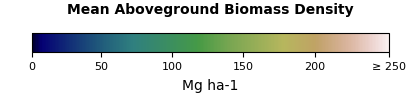

In [12]:
# Use the prewritten retrieve_wms_legend function
# This now keeps the legend in memory instead of saving to disk
legend_URL, legend_img_data = retrieve_wms_legend(WmtsTree, COLLECTION_NAME)

# Display the legend from memory
print("Legend URL:", legend_URL)
if legend_img_data:
    # Display the image from the in-memory data
    display(Image(data=legend_img_data))
else:
    # Fallback to displaying from URL if no data retrieved
    display(Image(url=legend_URL))

## GEDI Ecoregion Assessment

Let's look at AGBD over North America as it relates to [**EPA-defined Level I Ecoregions**](https://www.epa.gov/eco-research/ecoregions-north-america)! We'll read the shapefile directly from the S3 URL (https://dmap-prod-oms-edc.s3.us-east-1.amazonaws.com/ORD/Ecoregions/cec_na/na_cec_eco_l1.zip) without downloading it locally. Referring to maps from the EPA, we'll focus on different ecoregions to explore biomass patterns.

In [13]:
# URL to the shapefile
shapefile_url = "https://dmap-prod-oms-edc.s3.us-east-1.amazonaws.com/ORD/Ecoregions/cec_na/na_cec_eco_l1.zip"

# Read the shapefile directly from the URL
with urlopen(shapefile_url) as response:
    with tempfile.TemporaryDirectory() as tmpdir:
        # Save the zip content to a temporary file
        zip_path = f"{tmpdir}/ecoregions.zip"
        with open(zip_path, 'wb') as f:
            f.write(response.read())
        
        # Extract the zip file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(tmpdir)
        
        # Read the shapefile
        # The shapefile name might be different, let's check what's extracted
        import os
        shp_files = [f for f in os.listdir(tmpdir) if f.endswith('.shp')]
        if shp_files:
            shp_path = os.path.join(tmpdir, shp_files[0])
            aoi = gpd.read_file(shp_path).to_crs(4326)
        else:
            print("No shapefile found in the zip archive")

# Print the contents of the shapefile, check out what it contains
aoi

,NA_L1CODE,NA_L1NAME,NA_L1KEY,Shape_Leng,Shape_Area,geometry
0,0,WATER,0 WATER,2.213011e+05,1.101377e+09,"POLYGON ((-103.02853 20.33413, -103.02746 20.3..."
1,0,WATER,0 WATER,1.483641e+07,2.461369e+11,"POLYGON ((-88.00772 48.95993, -88.00105 48.958..."
2,1,ARCTIC CORDILLERA,1 ARCTIC CORDILLERA,1.891064e+04,2.093145e+07,"POLYGON ((-62.19257 57.96496, -62.21423 57.950..."
3,1,ARCTIC CORDILLERA,1 ARCTIC CORDILLERA,1.869981e+04,2.418667e+07,"POLYGON ((-63.06483 58.48813, -63.07401 58.490..."
4,1,ARCTIC CORDILLERA,1 ARCTIC CORDILLERA,1.979422e+04,2.643824e+07,"POLYGON ((-62.6774 58.5689, -62.66727 58.56149..."
...,...,...,...,...,...,...
2135,9,GREAT PLAINS,9 GREAT PLAINS,1.932425e+04,1.350594e+07,"POLYGON ((-94.80902 29.35153, -94.80875 29.351..."
2136,9,GREAT PLAINS,9 GREAT PLAINS,7.358517e+04,6.742279e+07,"POLYGON ((-94.50505 29.51011, -94.50414 29.51,..."
2137,9,GREAT PLAINS,9 GREAT PLAINS,5.253221e+04,2.883692e+07,"POLYGON ((-94.56432 29.53195, -94.56385 29.531..."
2138,9,GREAT PLAINS,9 GREAT PLAINS,7.239296e+05,6.820489e+09,"POLYGON ((-95.81152 30.5438, -95.81084 30.5424..."


In [14]:
# Subset to region of your choice - 
# per the EPA website, Level 1 has 15 different ecoregions.

focus_region = 6   # Change this number to visualize a different ecoregion!
aoi_subset = aoi[aoi['NA_L1CODE'] == str(focus_region)]
aoi_name = f'EPA North America {np.unique(aoi_subset['NA_L1NAME'])[0]}'

In [15]:
# Create our folium map, centered on the US
m = folium.Map([31.5,-97],zoom_start=3)

# Add EPA NA Level 1 Ecoregion of choice
folium.GeoJson(aoi_subset, name=aoi_name,style_function=lambda feature: {
        "fillColor": "transparent",
        "fillOpacity": 0,
        "color": "orange",
    }).add_to(m)

# Add WMS layer
folium.WmsTileLayer(
    url=GIBS_WMTS_URL.replace('wmts','wms'),
    name=COLLECTION_NAME,
    fmt="image/png",
    layers=COLLECTION_NAME,
    transparent=True,
    overlay=True,
    control=True,
    opacity=0.8
).add_to(m)

# Add WMS layer legend
FloatImage(legend_URL, bottom=0, left=0).add_to(m)

# Add layer toggle controls
folium.LayerControl().add_to(m)

m

Explore a few different ecoregions. What does the GEDI AGBD dataset tell you about the relative density of biomass of, for example, forests versus agricultural land?

## Summary

In this notebook we have successfully completed the following steps for the GEDI Aboveground Biomass Density dataset:

1. Installed and imported the necessary libraries
2. Fetched the dataset metadata from the STAC API using the collection name
3. Visualized biomass patterns across ecoregions

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).